# Packages

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import numpy as np

# Model

## Vector Quantizer

In [2]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost):
        super(VectorQuantizer, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        self.embeddings = nn.Embedding(num_embeddings, embedding_dim)
        self.embeddings.weight.data.uniform_(-1/self.num_embeddings, 1/self.num_embeddings)

    def forward(self, z):
        z_perm = z.permute(0, 2, 3, 1).contiguous()
        flat_z = z_perm.view(-1, self.embedding_dim)

        # Distance to embeddings
        distances = (flat_z.pow(2).sum(1, keepdim=True)
                    - 2 * flat_z @self.embeddings.weight.t()
                    + self.embeddings.weight.pow(2).sum(1))

        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.embeddings(encoding_indices).view(z_perm.shape)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()

        # Losses
        e_latent_loss = F.mse_loss(quantized.detach(), z)
        q_latent_loss = F.mse_loss(quantized, z.detach())
        loss = q_latent_loss + self.commitment_cost * e_latent_loss

        # Straight-through estimator
        quantized = z + (quantized - z).detach()

        return quantized, loss

## VQVAE

In [3]:
class VQVAE(nn.Module):
    def __init__(self, num_embeddings=128, embedding_dim=64, commitment_cost=0.25):
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, embedding_dim, 4, stride=2, padding=1),
            nn.ReLU()
        )
        self.quantizer = VectorQuantizer(num_embeddings, embedding_dim, commitment_cost)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embedding_dim, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        quantized, vq_loss = self.quantizer(z)
        x_hat = self.decoder(quantized)
        return x_hat, vq_loss

# Training Setup

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VQVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

loss_curve = []
epochs = 15

# Training

In [5]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        x_hat, vq_loss = model(x)
        recon_loss = F.mse_loss(x_hat, x)
        loss = recon_loss + vq_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_curve.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.3311
Epoch 2, Loss: 0.0743
Epoch 3, Loss: 0.0443
Epoch 4, Loss: 0.0382
Epoch 5, Loss: 0.0351
Epoch 6, Loss: 0.0335
Epoch 7, Loss: 0.0324
Epoch 8, Loss: 0.0315
Epoch 9, Loss: 0.0314
Epoch 10, Loss: 0.0312
Epoch 11, Loss: 0.0311
Epoch 12, Loss: 0.0311
Epoch 13, Loss: 0.0310
Epoch 14, Loss: 0.0309
Epoch 15, Loss: 0.0308


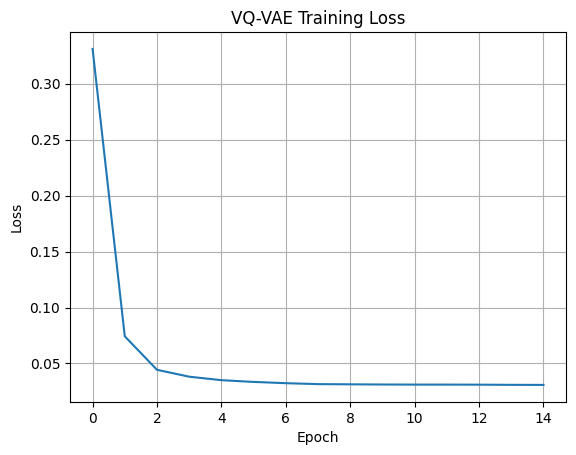

In [6]:
plt.plot(loss_curve)
plt.title("VQ-VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Reconsruction

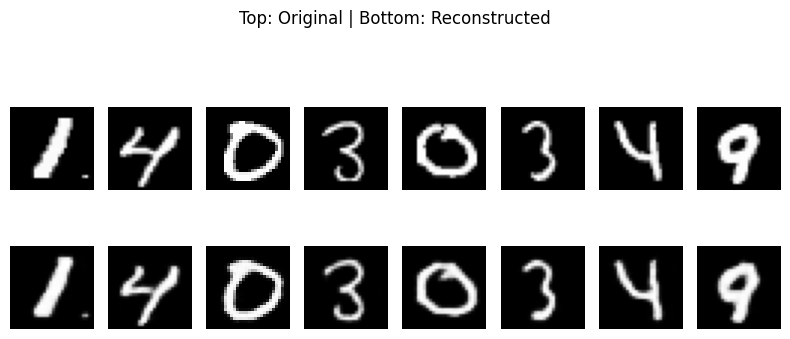

In [7]:
model.eval()
with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        x_hat, _ = model(x)
        x = x.cpu().numpy()
        x_hat = x_hat.cpu().numpy()
        # break

plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 8, i+1)
    plt.imshow(x[i][0], cmap='gray')
    plt.axis('off')
    plt.subplot(2, 8, i+9)
    plt.imshow(x_hat[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("Top: Original | Bottom: Reconstructed")
plt.tight_layout()
plt.show()

# Sampling: Fit a GMM on latents

In [8]:
all_latents = []
model.eval()
with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        z_e = model.encoder(x)
        z_e = z_e.permute(0, 2, 3, 1).contiguous().view(-1, model.quantizer.embedding_dim)
        all_latents.append(z_e.cpu())

all_latents = torch.cat(all_latents, dim=0).numpy()

print(all_latents.shape)

(2940000, 64)


In [9]:
# Randomly take 50000 sample to fit GMM faster
idx = np.random.choice(len(all_latents), 50000, replace=False)
subset = all_latents[idx]

print(subset.shape)  # (50000, 64)

(50000, 64)


In [10]:
gmm = GaussianMixture(
    n_components=100,
    covariance_type='full',
    reg_covar=1e-3,
    max_iter=300,        # default is 100, increase it
    tol=1e-3,            # loosen tolerance
    n_init=3,            # try 3 random initializations, pick best
    init_params='kmeans', # better init than random
    random_state=0,
    verbose=1
)

gmm.fit(subset)

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
Initialization converged.
Initialization 1
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
Initialization converged.
Initialization 2
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
Initialization converged.


,"n_components n_components: int, default=1The number of mixture components.",100
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",0.001
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",300
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",3
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [11]:
samples = gmm.sample(n_samples=16*7*7)[0]
samples = torch.tensor(samples, dtype=torch.float32).view(16, 7, 7, -1).to(device)

d:\Learn\.gen_ai_math\Lib\site-packages\sklearn\mixture\_base.py:468: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


In [12]:
with torch.no_grad():
    flat = samples.view(-1, samples.shape[-1])
    dist = (flat.pow(2).sum(1, keepdim=True)
            - 2 * flat @ model.quantizer.embeddings.weight.t()
            + model.quantizer.embeddings.weight.pow(2).sum(1))
    encoding_indices = torch.argmin(dist, dim=1)
    quantized = model.quantizer.embeddings(encoding_indices)
    quantized = quantized.view(16, 7, 7, -1).permute(0, 3, 1, 2).contiguous()
    generated = model.decoder(quantized)

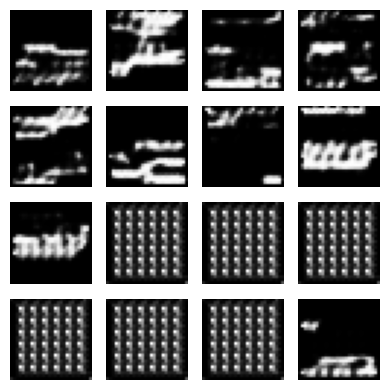

In [13]:
plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated[i][0].cpu(), cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


# Sampling: Fit PixelCNN on Latents

## PixelCNN

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.mask_type = mask_type
        H, W = self.weight.shape[2], self.weight.shape[3]
        mask = torch.ones_like(self.weight)
        mask[:, :, H//2, W//2 + (1 if mask_type == 'B' else 0):] = 0
        mask[:, :, H//2 + 1:] = 0
        self.register_buffer('mask', mask)

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)


class PixelCNN(nn.Module):
    def __init__(self, n_embeddings=128, hidden=64, n_layers=6):
        super().__init__()
        self.embedding = nn.Embedding(n_embeddings, hidden)
        layers = [MaskedConv2d('A', hidden, hidden, 7, 1, 3)]
        for _ in range(n_layers):
            layers += [
                MaskedConv2d('B', hidden, hidden, 7, 1, 3),
                nn.ReLU()
            ]
        layers.append(nn.Conv2d(hidden, n_embeddings, 1))  # logits over codebook
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, 7, 7) index map
        x = self.embedding(x).permute(0, 3, 1, 2)  # (B, hidden, 7, 7)
        return self.net(x)                          # (B, n_embeddings, 7, 7)

    @torch.no_grad()
    def sample(self, n, device):
        out = torch.zeros(n, 7, 7, dtype=torch.long).to(device)
        for i in range(7):
            for j in range(7):
                logits = self.forward(out)[:, :, i, j]   # (B, n_embeddings)
                probs  = F.softmax(logits, dim=-1)
                out[:, i, j] = torch.multinomial(probs, 1).squeeze(1)
        return out  # (B, 7, 7)

## Train

In [15]:
# collect index maps from real images
all_index_maps = []
model.eval()
with torch.no_grad():
    for x, _ in train_loader:
        x = x.to(device)
        z_e = model.encoder(x)
        z_perm = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z_perm.view(-1, model.quantizer.embedding_dim)
        dist = (flat.pow(2).sum(1, keepdim=True)
                - 2 * flat @ model.quantizer.embeddings.weight.t()
                + model.quantizer.embeddings.weight.pow(2).sum(1))
        indices = torch.argmin(dist, dim=1).view(-1, 7, 7)
        all_index_maps.append(indices.cpu())

all_index_maps = torch.cat(all_index_maps)  # (60000, 7, 7)

# dataloader for index maps
index_dataset = torch.utils.data.TensorDataset(all_index_maps)
index_loader  = torch.utils.data.DataLoader(index_dataset, batch_size=128, shuffle=True)

# train
pixel_cnn = PixelCNN(n_embeddings=128, hidden=64, n_layers=6).to(device)
optimizer  = torch.optim.Adam(pixel_cnn.parameters(), lr=1e-3)

for epoch in range(100):
    total_loss = 0
    for (idx_map,) in index_loader:
        idx_map = idx_map.to(device)
        logits  = pixel_cnn(idx_map)                           # (B, 128, 7, 7)
        loss    = F.cross_entropy(logits, idx_map)             # predict each index
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(index_loader):.4f}")

Epoch 1, Loss: 1.7029
Epoch 2, Loss: 1.2220
Epoch 3, Loss: 1.1640
Epoch 4, Loss: 1.1340
Epoch 5, Loss: 1.1140
Epoch 6, Loss: 1.0971
Epoch 7, Loss: 1.0855
Epoch 8, Loss: 1.0757
Epoch 9, Loss: 1.0653
Epoch 10, Loss: 1.0579
Epoch 11, Loss: 1.0490
Epoch 12, Loss: 1.0388
Epoch 13, Loss: 1.0289
Epoch 14, Loss: 1.0192
Epoch 15, Loss: 1.0117
Epoch 16, Loss: 1.0048
Epoch 17, Loss: 0.9983
Epoch 18, Loss: 0.9929
Epoch 19, Loss: 0.9872
Epoch 20, Loss: 0.9829
Epoch 21, Loss: 0.9787
Epoch 22, Loss: 0.9745
Epoch 23, Loss: 0.9699
Epoch 24, Loss: 0.9661
Epoch 25, Loss: 0.9624
Epoch 26, Loss: 0.9590
Epoch 27, Loss: 0.9552
Epoch 28, Loss: 0.9516
Epoch 29, Loss: 0.9486
Epoch 30, Loss: 0.9459
Epoch 31, Loss: 0.9432
Epoch 32, Loss: 0.9406
Epoch 33, Loss: 0.9376
Epoch 34, Loss: 0.9340
Epoch 35, Loss: 0.9323
Epoch 36, Loss: 0.9300
Epoch 37, Loss: 0.9273
Epoch 38, Loss: 0.9247
Epoch 39, Loss: 0.9227
Epoch 40, Loss: 0.9201
Epoch 41, Loss: 0.9181
Epoch 42, Loss: 0.9169
Epoch 43, Loss: 0.9146
Epoch 44, Loss: 0.91

## Sample

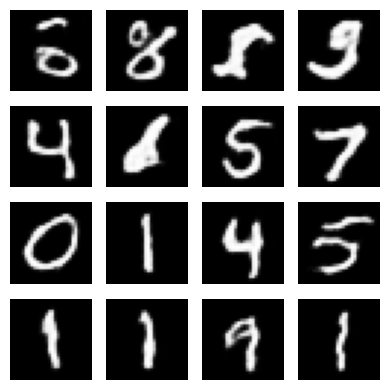

In [16]:
pixel_cnn.eval()
sampled_indices = pixel_cnn.sample(16, device)             # (16, 7, 7)

with torch.no_grad():
    quantized = model.quantizer.embeddings(sampled_indices)        # (16, 7, 7, 64)
    quantized = quantized.permute(0, 3, 1, 2).contiguous()        # (16, 64, 7, 7)
    generated = model.decoder(quantized)

plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated[i][0].cpu(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()